In [1]:
import os
print(os.getcwd())

C:\Users\HP


In [4]:
print(os.listdir())

['.arduinoIDE', '.bash_history', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.stm32cubeide', '.stm32cubemx', '.stmcube', '.stmcufinder', '.viminfo', '.VirtualBox', '.vscode', '3D Objects', '3matplotlib.ipynb', 'AppData', 'Application Data', 'Book1.csv', 'Bookibm1.csv', 'Contacts', 'Cookies', 'Desktop', 'Document from Pugal Pugal.pdf', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Master_notes (2) (1).ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.0.regtrans-ms', 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.1.regtrans-ms', 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.2.regtrans-ms', 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf', 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001

In [5]:
!pip install pandas
import pandas as pd


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#df = pd.read_csv("Bookibm1.csv")
#df.head()


In [25]:
#df.tail()

In [33]:
with open('Bookibm1.csv', 'r', encoding='utf-8') as f:
    total_lines = sum(1 for line in f)
print(total_lines)  # should be ~5601 (including header)

2129


In [34]:
import pandas as pd

df = pd.read_csv(
    'Bookibm1.csv',
    encoding='utf-8',      # or 'latin1' if utf-8 fails
    sep=',',               # make sure this matches your CSV
    engine='python',       # safer for messy CSVs
    quotechar='"',         # handles quoted commas
    on_bad_lines='skip'    # skips problematic rows
)

print(df.shape)           # check number of rows and columns
print(df.head())  

(2128, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  9237-HQITU      1  United States  California  Los Angeles     90005   
1  9305-CDSKC      1  United States  California  Los Angeles     90006   
2  7892-POOKP      1  United States  California  Los Angeles     90010   
3  0280-XJGEX      1  United States  California  Los Angeles     90015   
4  6467-CHFZW      1  United States  California  Los Angeles     90028   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
1  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
2  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
3  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   
4  34.099869, -118.326843  34.099869 -118.326843    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [28]:
#df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
#df.dropna(inplace=True)

In [35]:
df['Churn Label'] = df['Churn Label'].astype(str).str.strip().str.capitalize()
print(df['Churn Label'].value_counts())

Churn Label
Yes    1162
No      966
Name: count, dtype: int64


In [36]:
print(df['Churn Label'].unique())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str


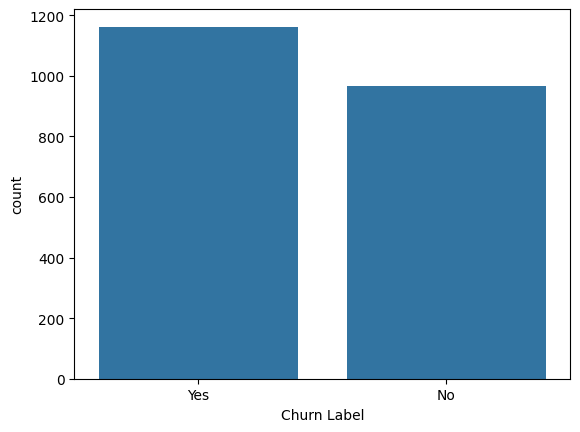

In [37]:
sns.countplot(x='Churn Label', data=df)
plt.show()

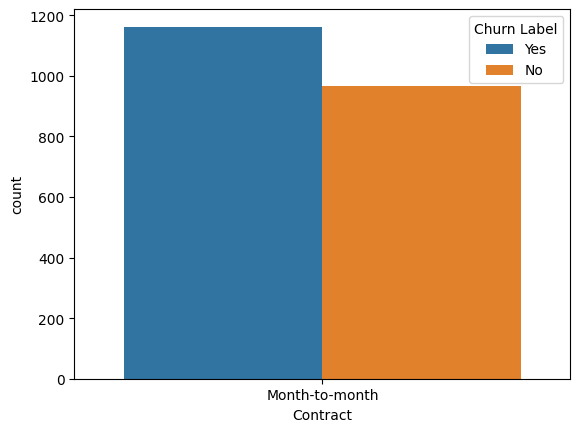

In [38]:
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.show()

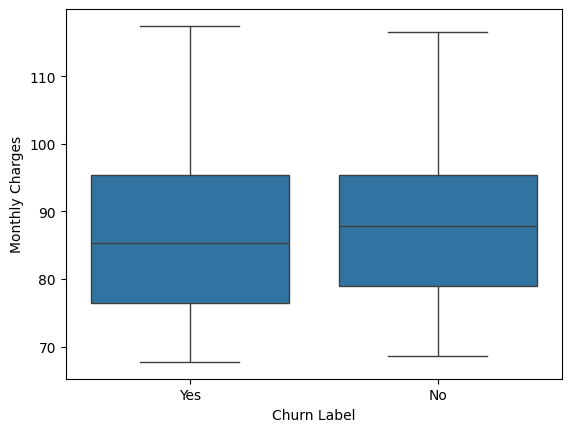

In [40]:
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.show()

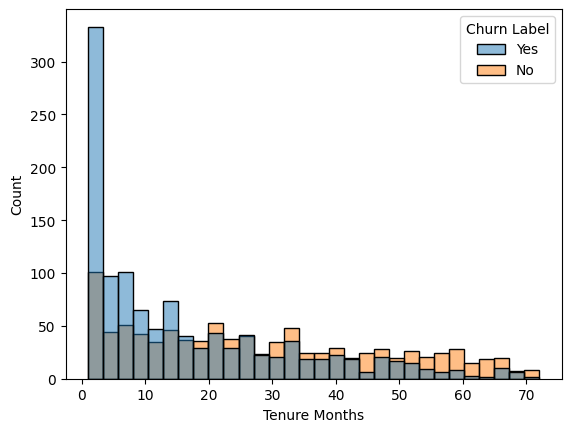

In [42]:
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30)
plt.show()

In [43]:
df['High_Risk'] = (
    (df['Tenure Months'] < 12) &
    (df['Contract'] == 'Month-to-month') &
    (df['Monthly Charges'] > 70)
).astype(int)

In [45]:
print(df[['Tenure Months','Contract','Monthly Charges','High_Risk']].head(10))

   Tenure Months        Contract  Monthly Charges  High_Risk
0              2  Month-to-month            70.70          1
1              8  Month-to-month            99.65          1
2             28  Month-to-month           104.80          0
3             49  Month-to-month           103.70          0
4             47  Month-to-month            99.35          0
5              5  Month-to-month            69.70          0
6             34  Month-to-month           106.35          0
7             11  Month-to-month            97.85          1
8              2  Month-to-month            80.65          1
9             15  Month-to-month            99.10          0
